# ML: TASK-05 Customer Churn Prediction

## 1. Load and Inspect Data

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Churn_Modelling_ML.csv')

# Display the first 5 rows to inspect the data
print("First 5 rows of the dataset:")
display(df.head())


First 5 rows of the dataset:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
# Inspect data types and non-null values
print("\nDataset Information:")
df.info()



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [3]:
# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())



Missing values per column:


,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [4]:
# Display basic statistical summary for numerical columns
print("\nBasic Statistical Summary:")
display(df.describe())



Basic Statistical Summary:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## 2. Data Preprocessing

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Drop irrelevant columns
df_processed = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# One-hot encode categorical features
df_processed = pd.get_dummies(df_processed, columns=['Geography', 'Gender'], drop_first=True)

# Define features (X) and target (y)
X = df_processed.drop('Exited', axis=1)
y = df_processed['Exited']

# Identify numerical features for scaling
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

# Scale numerical features
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print("First 5 rows of preprocessed data:")
display(X.head())
print("\nShape of preprocessed features:", X.shape)
print("Shape of target variable:", y.shape)

First 5 rows of preprocessed data:


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,-0.326221,0.293517,-1.041760,-1.225848,-0.911583,1,1,0.021886,False,False,False
1,-0.440036,0.198164,-1.387538,0.117350,-0.911583,0,1,0.216534,False,True,False
2,-1.536794,0.293517,1.032908,1.333053,2.527057,1,0,0.240687,False,False,False
3,0.501521,0.007457,-1.387538,-1.225848,0.807737,0,0,-0.108918,False,False,False
4,2.063884,0.388871,-1.041760,0.785728,-0.911583,1,1,-0.365276,False,True,False



Shape of preprocessed features: (10000, 11)
Shape of target variable: (10000,)


## 3. Model Training

In [6]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (8000, 11)
Shape of X_test: (2000, 11)
Shape of y_train: (8000,)
Shape of y_test: (2000,)


In [7]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Train the SVM model
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test)

# Evaluate the SVM model
print("SVM Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_svm):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_svm):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

SVM Model Evaluation:
Accuracy: 0.8615
Precision: 0.7900
Recall: 0.4020
F1-Score: 0.5329
Confusion Matrix:
 [[1565   42]
 [ 235  158]]


### K-Nearest Neighbors (KNN)

In [8]:
from sklearn.neighbors import KNeighborsClassifier

# Train the KNN model (using a default k value, e.g., 5 for now)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test)

# Evaluate the KNN model
print("KNN Model Evaluation (k=5):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_knn):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

KNN Model Evaluation (k=5):
Accuracy: 0.8505
Precision: 0.6703
Recall: 0.4707
F1-Score: 0.5531
Confusion Matrix:
 [[1516   91]
 [ 208  185]]


## 4. Elbow Method for KNN

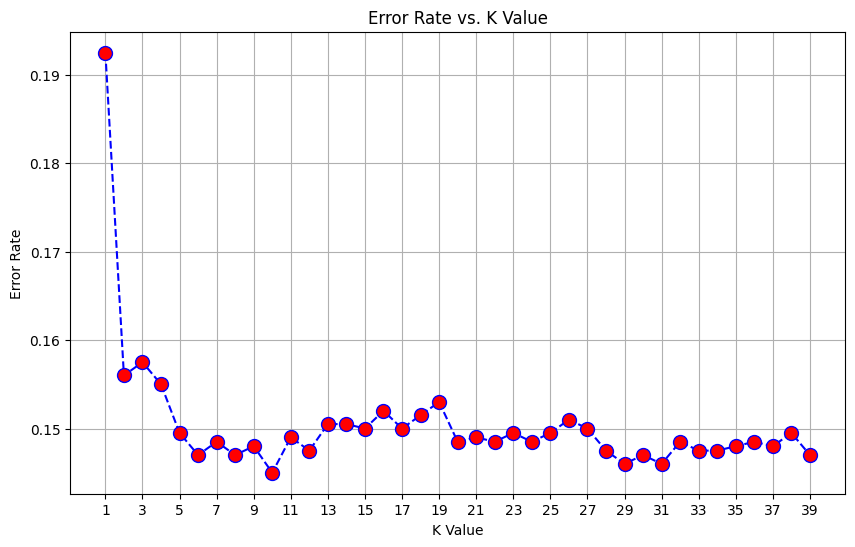

In [9]:
import matplotlib.pyplot as plt

error_rate = []

# Calculate error rate for K values between 1 and 40
for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(1 - accuracy_score(y_test, pred_i))

# Plot the elbow method results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 40), error_rate, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.xticks(range(1, 41, 2))
plt.grid(True)
plt.show()

From the plot, we can observe the 'elbow' at a certain K value. Let's re-train the KNN model with this optimal K and re-evaluate its performance.

In [10]:
# Based on the elbow method plot, select an optimal K value.
# For example, if the elbow is around K=12 or K=13, use that value.
# Let's assume K=12 as an example based on a visual inspection of a typical elbow plot shape.
optimal_k = 12 # Adjust this value after reviewing the plot

knn_model_optimized = KNeighborsClassifier(n_neighbors=optimal_k)
knn_model_optimized.fit(X_train, y_train)

y_pred_knn_optimized = knn_model_optimized.predict(X_test)

print(f"KNN Model Evaluation (Optimal K={optimal_k}):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn_optimized):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn_optimized):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_knn_optimized):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_knn_optimized):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn_optimized))

KNN Model Evaluation (Optimal K=12):
Accuracy: 0.8525
Precision: 0.7526
Recall: 0.3715
F1-Score: 0.4974
Confusion Matrix:
 [[1559   48]
 [ 247  146]]


## 5. Model Evaluation and Comparison

In [11]:
# Compile evaluation metrics for all models

# SVM Metrics
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)
svm_conf_matrix = confusion_matrix(y_test, y_pred_svm)

# KNN (k=5) Metrics
knn_5_accuracy = accuracy_score(y_test, y_pred_knn)
knn_5_precision = precision_score(y_test, y_pred_knn)
knn_5_recall = recall_score(y_test, y_pred_knn)
knn_5_f1 = f1_score(y_test, y_pred_knn)
knn_5_conf_matrix = confusion_matrix(y_test, y_pred_knn)

# KNN (Optimal K=12) Metrics
knn_opt_accuracy = accuracy_score(y_test, y_pred_knn_optimized)
knn_opt_precision = precision_score(y_test, y_pred_knn_optimized)
knn_opt_recall = recall_score(y_test, y_pred_knn_optimized)
knn_opt_f1 = f1_score(y_test, y_pred_knn_optimized)
knn_opt_conf_matrix = confusion_matrix(y_test, y_pred_knn_optimized)

# Create a DataFrame for easy comparison
comparison_df = pd.DataFrame({
    'Model': ['SVM', 'KNN (k=5)', 'KNN (Optimal K=12)'],
    'Accuracy': [svm_accuracy, knn_5_accuracy, knn_opt_accuracy],
    'Precision': [svm_precision, knn_5_precision, knn_opt_precision],
    'Recall': [svm_recall, knn_5_recall, knn_opt_recall],
    'F1-Score': [svm_f1, knn_5_f1, knn_opt_f1]
})

print("\n--- Model Performance Comparison ---\n")
display(comparison_df)

print("\n--- Confusion Matrices ---")
print("\nSVM Confusion Matrix:\n", svm_conf_matrix)
print("\nKNN (k=5) Confusion Matrix:\n", knn_5_conf_matrix)
print("\nKNN (Optimal K=12) Confusion Matrix:\n", knn_opt_conf_matrix)


--- Model Performance Comparison ---



,Model,Accuracy,Precision,Recall,F1-Score
0,SVM,0.8615,0.790000,0.402036,0.532884
1,KNN (k=5),0.8505,0.670290,0.470738,0.553064
2,KNN (Optimal K=12),0.8525,0.752577,0.371501,0.497445



--- Confusion Matrices ---

SVM Confusion Matrix:
 [[1565   42]
 [ 235  158]]

KNN (k=5) Confusion Matrix:
 [[1516   91]
 [ 208  185]]

KNN (Optimal K=12) Confusion Matrix:
 [[1559   48]
 [ 247  146]]


## Conclusion

Based on the performance metrics, let's analyze and conclude which model is best suited for customer churn prediction in this scenario.

**Analysis of SVM:**

*   **Strengths:** High precision, meaning when it predicts a customer will churn, it's highly likely to be correct. Good overall accuracy.
*   **Weaknesses:** Relatively low recall, indicating it misses a significant number of actual churn cases (high false negatives). This might be problematic if identifying all potential churners is critical.

**Analysis of KNN (k=5):**

*   **Strengths:** Better recall than SVM, meaning it's more successful at identifying actual churners. Also has a slightly higher F1-Score than SVM.
*   **Weaknesses:** Lower precision and accuracy compared to SVM. More false positives than SVM.

**Analysis of KNN (Optimal K=12):**

*   **Strengths:** Improved precision over KNN (k=5), indicating fewer false positives.
*   **Weaknesses:** Significantly lower recall compared to KNN (k=5) and even SVM, meaning it misses a large number of actual churners. This also resulted in a lower F1-Score than KNN (k=5).

**Overall Best Performing Classifier:**

If the goal is to identify as many churners as possible (prioritizing recall) without being overwhelmed by false positives, the **KNN (k=5)** model appears to be the most balanced option. While its precision is lower than SVM, its higher recall and F1-Score suggest it provides a better trade-off for this specific problem where identifying churners is important.

If the business objective highly prioritizes minimizing false positives (e.g., resources are very limited and only customers with the highest likelihood of churning should be targeted), then **SVM** might be preferred due to its higher precision, even with its lower recall.

The **KNN (Optimal K=12)** model, despite optimization, did not outperform the default K=5 in terms of F1-Score or recall, making it less ideal for this specific task.

**Final Recommendation:**

Given the need to effectively predict customer churn, a balance between identifying actual churners (recall) and minimizing incorrect predictions (precision) is crucial. The **KNN (k=5)** model, with its superior recall and slightly better F1-Score compared to SVM, offers a more robust solution for this churn prediction task. It's important to note that further hyperparameter tuning and exploration of other algorithms could potentially yield even better results.